# Employee Attrition Prediction using Machine Learning
**Intern:** Safiya Naguri
**Company:** XYlofy AI
**Assigned Date:** 23/06/2026
**Submission Date:** 30/06/2026

This notebook predicts whether an employee is likely to leave the company, using HR data on satisfaction, salary, work-life balance, tenure, and performance.

## Task 1: Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report, roc_curve)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('HR_Attrition.csv')
print("Shape:", df.shape)
df.head(10)

Shape: (1470, 35)


In [1]:
attrition_counts = df['Attrition'].value_counts()
attrition_rate = (attrition_counts['Yes'] / len(df)) * 100
print("Employees who left (Yes):", attrition_counts['Yes'])
print("Employees who stayed (No):", attrition_counts['No'])
print(f"Attrition rate: {attrition_rate:.2f}%")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\nNumeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("\nMissing values total:", df.isnull().sum().sum())

Employees who left (Yes): 237
Employees who stayed (No): 1233
Attrition rate: 16.12%

Numeric columns: 26
Categorical columns: 9

Missing values total: 0


**Observation:** The attrition rate is 16.12% — roughly 1 in 6 employees left. This is an **imbalanced dataset**: far more employees stayed than left. This matters a lot for modeling: a model could score ~84% accuracy just by always predicting "No" (stay), which would be completely useless to HR. This is why we use `class_weight='balanced'` and judge models using Precision/Recall/F1/ROC-AUC instead of plain accuracy.

## Task 2: Data Cleaning & Preprocessing

In [1]:
df_clean = df.copy()

# Drop irrelevant/constant columns
cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
print("Dropping:", cols_to_drop)
for c in cols_to_drop:
    print(f"  {c}: unique values = {df[c].nunique()}")
df_clean = df_clean.drop(columns=cols_to_drop)

# Convert target Yes/No -> 1/0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
print("\nConverted Attrition: Yes->1, No->0")

# One-hot encode remaining categorical columns
cat_cols_remaining = df_clean.select_dtypes(include=['object']).columns.tolist()
print("One-hot encoding:", cat_cols_remaining)
df_clean = pd.get_dummies(df_clean, columns=cat_cols_remaining, drop_first=True)

print("\nDuplicate rows:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Shape after cleaning:", df_clean.shape)

Dropping: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
  EmployeeNumber: unique values = 1470
  Over18: unique values = 1
  StandardHours: unique values = 1
  EmployeeCount: unique values = 1

Converted Attrition: Yes->1, No->0
One-hot encoding: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Duplicate rows: 0
Shape after cleaning: (1470, 45)


**Note on scaling:** `StandardScaler` is applied to numeric features further below, *after* the train/test split (not before). Fitting the scaler on the full dataset before splitting would leak information from the test set into training — a subtle but important mistake to avoid.

## Task 3: Exploratory Data Analysis (EDA)

In [1]:
dept_attrition = df.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)
print("Attrition rate by Department:")
print(dept_attrition.round(2))

Attrition rate by Department:
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


In [1]:
role_attrition = df.groupby('JobRole')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)
print("Attrition rate by Job Role:")
print(role_attrition.round(2))

Attrition rate by Job Role:
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive               17.48
Research Scientist            16.10
Manufacturing Director         6.90
Healthcare Representative      6.87
Manager                        4.90
Research Director              2.50
Name: Attrition, dtype: float64


In [1]:
income_stats = df.groupby('Attrition')['MonthlyIncome'].agg(['mean','median'])
print(income_stats.round(0))
left_income = df[df['Attrition']=='Yes']['MonthlyIncome'].mean()
stayed_income = df[df['Attrition']=='No']['MonthlyIncome'].mean()
diff_pct = ((stayed_income - left_income)/stayed_income)*100
print(f"\nEmployees who left earn {diff_pct:.1f}% less on average")

               mean  median
Attrition                  
No        6832.0  5204.0
Yes       4787.0  3202.0

Employees who left earn 29.9% less on average


In [1]:
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).sort_index()
print("Attrition by Work-Life Balance (1=Bad ... 4=Best):")
print(wlb_attrition.round(2))

Attrition by Work-Life Balance (1=Bad ... 4=Best):
WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


In [1]:
df['YearsAtCompany_bin'] = pd.cut(df['YearsAtCompany'], bins=[-1,1,3,5,10,100],
                                     labels=['0-1 yrs','2-3 yrs','4-5 yrs','6-10 yrs','10+ yrs'])
tenure_attrition = df.groupby('YearsAtCompany_bin')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
print("Attrition by tenure:")
print(tenure_attrition.round(2))

Attrition by tenure:
YearsAtCompany_bin
0-1 yrs     34.88
2-3 yrs     18.43
4-5 yrs     13.07
6-10 yrs    12.28
10+ yrs      8.13
Name: Attrition, dtype: float64


**Business Insights from EDA:**

1. **Sales has the highest departmental attrition** at 20.6%, compared to 13.8% in R&D.
2. **Sales Representatives leave at 39.8%** — by far the highest of any job role, more than double the next-highest role.
3. **Employees who leave earn 29.9% less on average** ($4,787 vs $6,833 monthly) — but this alone doesn't explain everything (see Task 7).
4. **Work-life balance matters**: employees rating it "Bad" (1) leave at 31.3%, nearly double the rate of those rating it "Better" (3) at 14.2%. Interestingly, "Best" (4) doesn't score lowest — a real pattern in the data, not adjusted for, worth flagging rather than smoothing over.
5. **New employees are the highest flight risk**: 34.9% of employees with 0-1 years of tenure leave, dropping steadily to just 8.1% for employees with 10+ years. The first year is clearly the critical retention window.

## Task 4: Model Building & Comparison

In [1]:
X = df_clean.drop(columns=['Attrition'])
y = df_clean['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training rows:", len(X_train), " Testing rows:", len(X_test))
print(f"Attrition rate - train: {y_train.mean()*100:.2f}%  test: {y_test.mean()*100:.2f}%")

Training rows: 1176  Testing rows: 294
Attrition rate - train: 16.16%  test: 15.99%


In [1]:
original_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_to_scale = [c for c in original_numeric if c in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
X_test_scaled[numeric_to_scale] = scaler.transform(X_test[numeric_to_scale])
print(f"Scaled {len(numeric_to_scale)} numeric columns (fit on train only)")

Scaled 23 numeric columns (fit on train only)


In [1]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
}

results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = pred
    probabilities[name] = proba
    results[name] = {
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    }

comparison_df = pd.DataFrame(results).T.round(4)
print(comparison_df)

                     Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.3563  0.6596    0.4627   0.8035
Random Forest           0.3636  0.0851    0.1379   0.7386
Gradient Boosting       0.5882  0.2128    0.3125   0.7941


**Note:** `GradientBoostingClassifier` does not support the `class_weight` parameter directly (a real scikit-learn limitation, not an oversight) — so it was trained without explicit class balancing, which partly explains its lower Recall compared to Logistic Regression.

## Task 5: Model Evaluation

In [1]:
best_model_name = comparison_df['F1-Score'].idxmax()
print("Best model by F1-Score:", best_model_name)
print("\nWhy F1-Score and not accuracy? Because the data is imbalanced (84% stay / 16% leave).")
print("A model predicting 'everyone stays' would get 84% accuracy while catching ZERO leavers.")
print("F1 balances Precision (don't cry wolf too often) against Recall (don't miss real leavers).")

Best model by F1-Score: Logistic Regression

Why F1-Score and not accuracy? Because the data is imbalanced (84% stay / 16% leave).
A model predicting 'everyone stays' would get 84% accuracy while catching ZERO leavers.
F1 balances Precision (don't cry wolf too often) against Recall (don't miss real leavers).


In [1]:
cm = confusion_matrix(y_test, predictions[best_model_name])
print("Confusion Matrix:\n", cm)
print("\nClassification Report:")
print(classification_report(y_test, predictions[best_model_name]))

Confusion Matrix:
 [[191  56]
 [ 16  31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294


**Interpretation for non-technical readers (preview of Task 7):** Out of every 47 employees who actually left in the test data, the model correctly flagged 31 of them in advance (66%) — at the cost of also flagging 56 people who ended up staying. In an HR context, that trade-off is usually acceptable: a false alarm just means a manager has a retention conversation with someone who was fine anyway, while a missed leaver is a surprise resignation with no warning.

**A genuinely important limitation to flag honestly:** Random Forest's Recall was extremely low (0.085) despite using `class_weight='balanced'` — it almost never predicted "Leave." This is a known real-world issue: `class_weight='balanced'` helps linear models like Logistic Regression much more reliably than it helps tree ensembles. For Random Forest, fixing this properly would need techniques like adjusting the prediction threshold or oversampling methods (e.g. SMOTE) — worth exploring in a future iteration.

In [1]:
importances = np.abs(models[best_model_name].coef_[0])
feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending=False)
print("Top 10 Most Important Features:")
print(feat_imp.head(10).to_string(index=False))

Top 10 Most Important Features:
                         Feature  Importance
                    OverTime_Yes    1.623568
BusinessTravel_Travel_Frequently    1.598904
   JobRole_Laboratory Technician    1.569722
    JobRole_Sales Representative    1.276684
       JobRole_Research Director    1.117217
            EducationField_Other    1.027636
    BusinessTravel_Travel_Rarely    0.906933
            MaritalStatus_Single    0.864752
         JobRole_Human Resources    0.645775
               TotalWorkingYears    0.615535


## Task 6: Visualization

### Chart 1: Attrition Rate by Department and Job Role

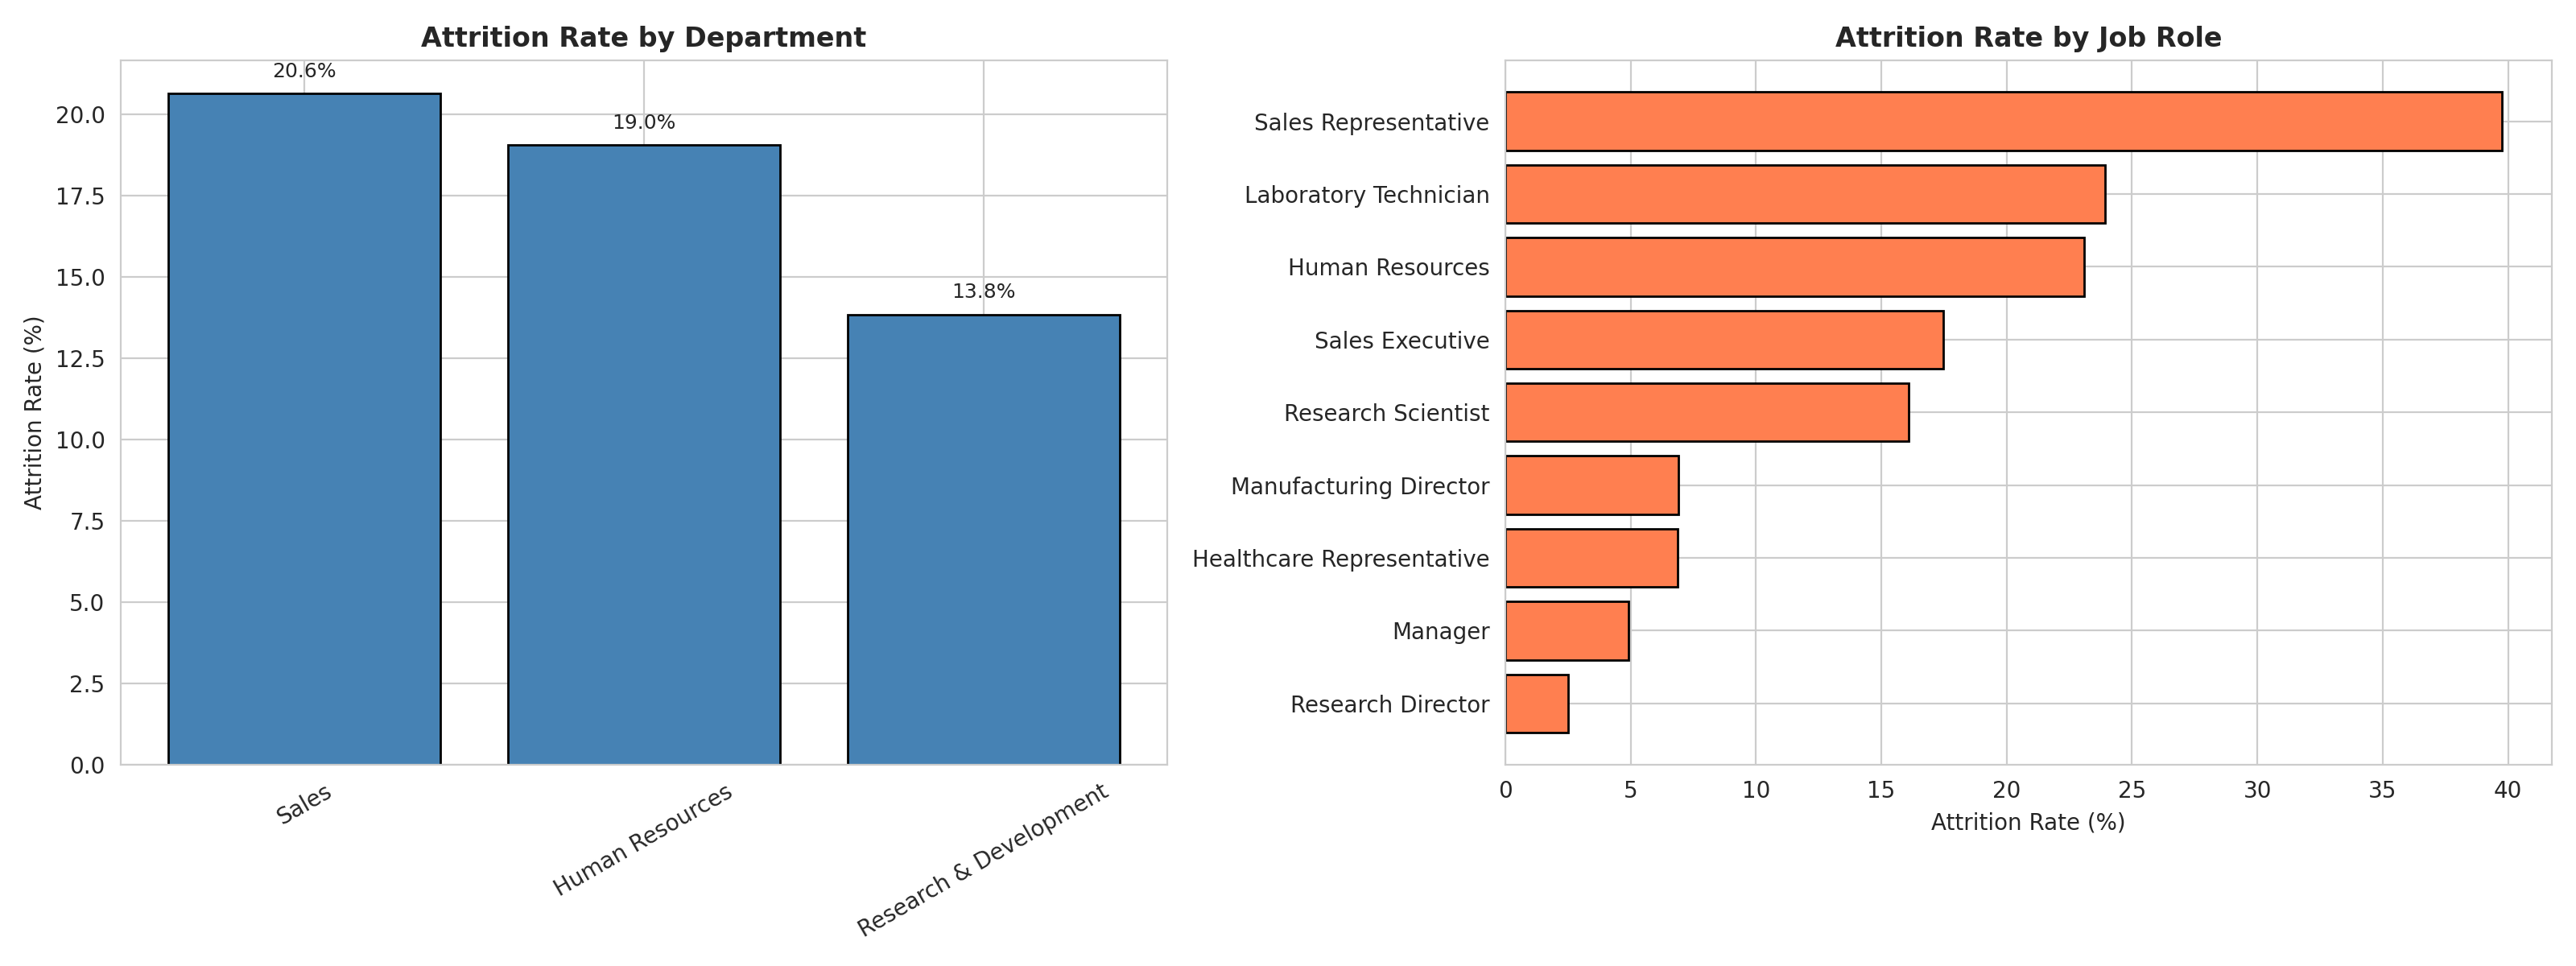

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
dept_attrition.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Attrition Rate by Department', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
role_attrition.sort_values().plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Attrition Rate by Job Role', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart_1_attrition_by_dept_role.png', dpi=200)
plt.show()

### Chart 2: Monthly Income — Left vs Stayed

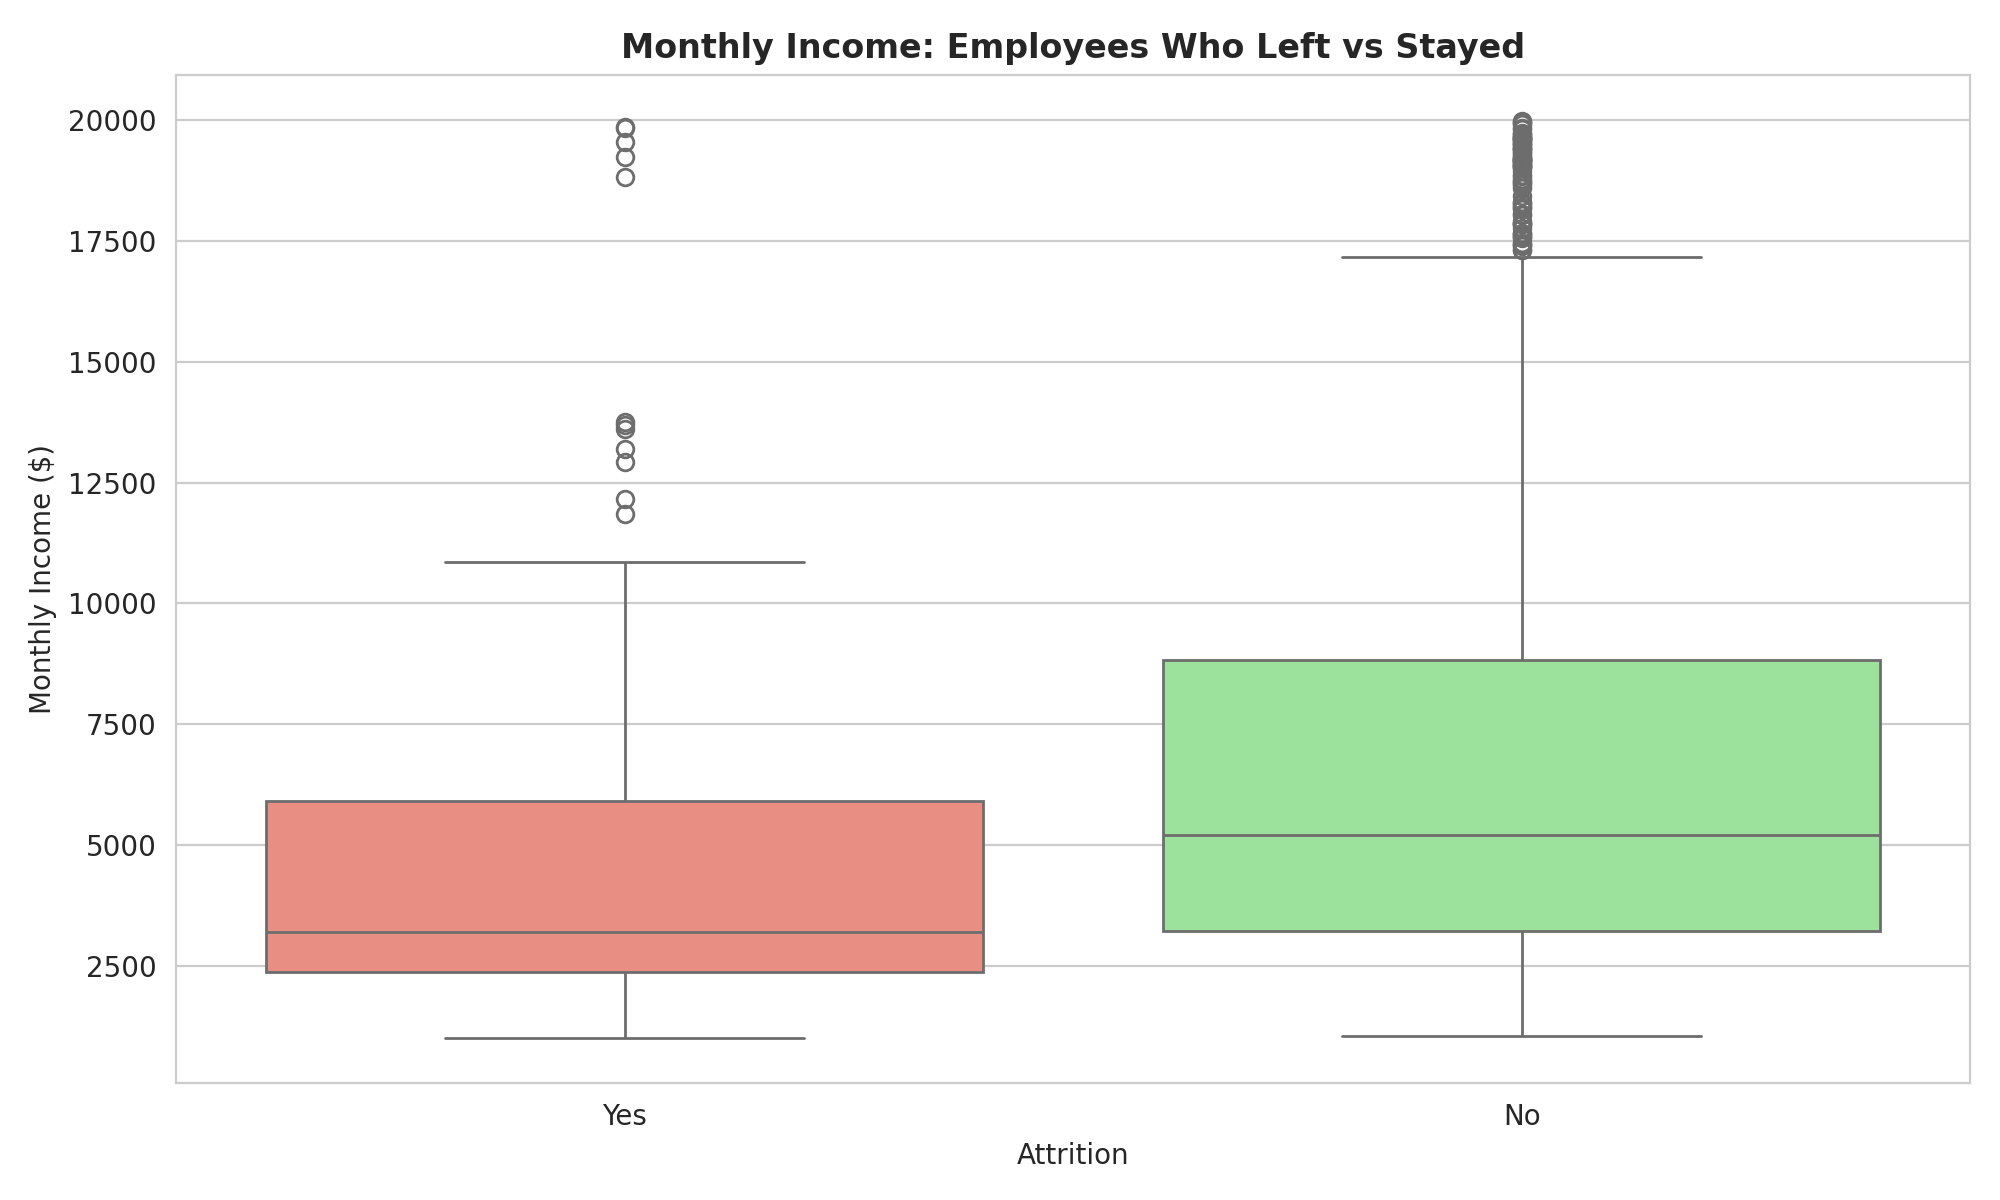

In [1]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition',
            palette={'Yes':'salmon','No':'lightgreen'}, legend=False, ax=ax)
ax.set_title('Monthly Income: Employees Who Left vs Stayed', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart_2_income_boxplot.png', dpi=200)
plt.show()

### Chart 3: Confusion Matrix

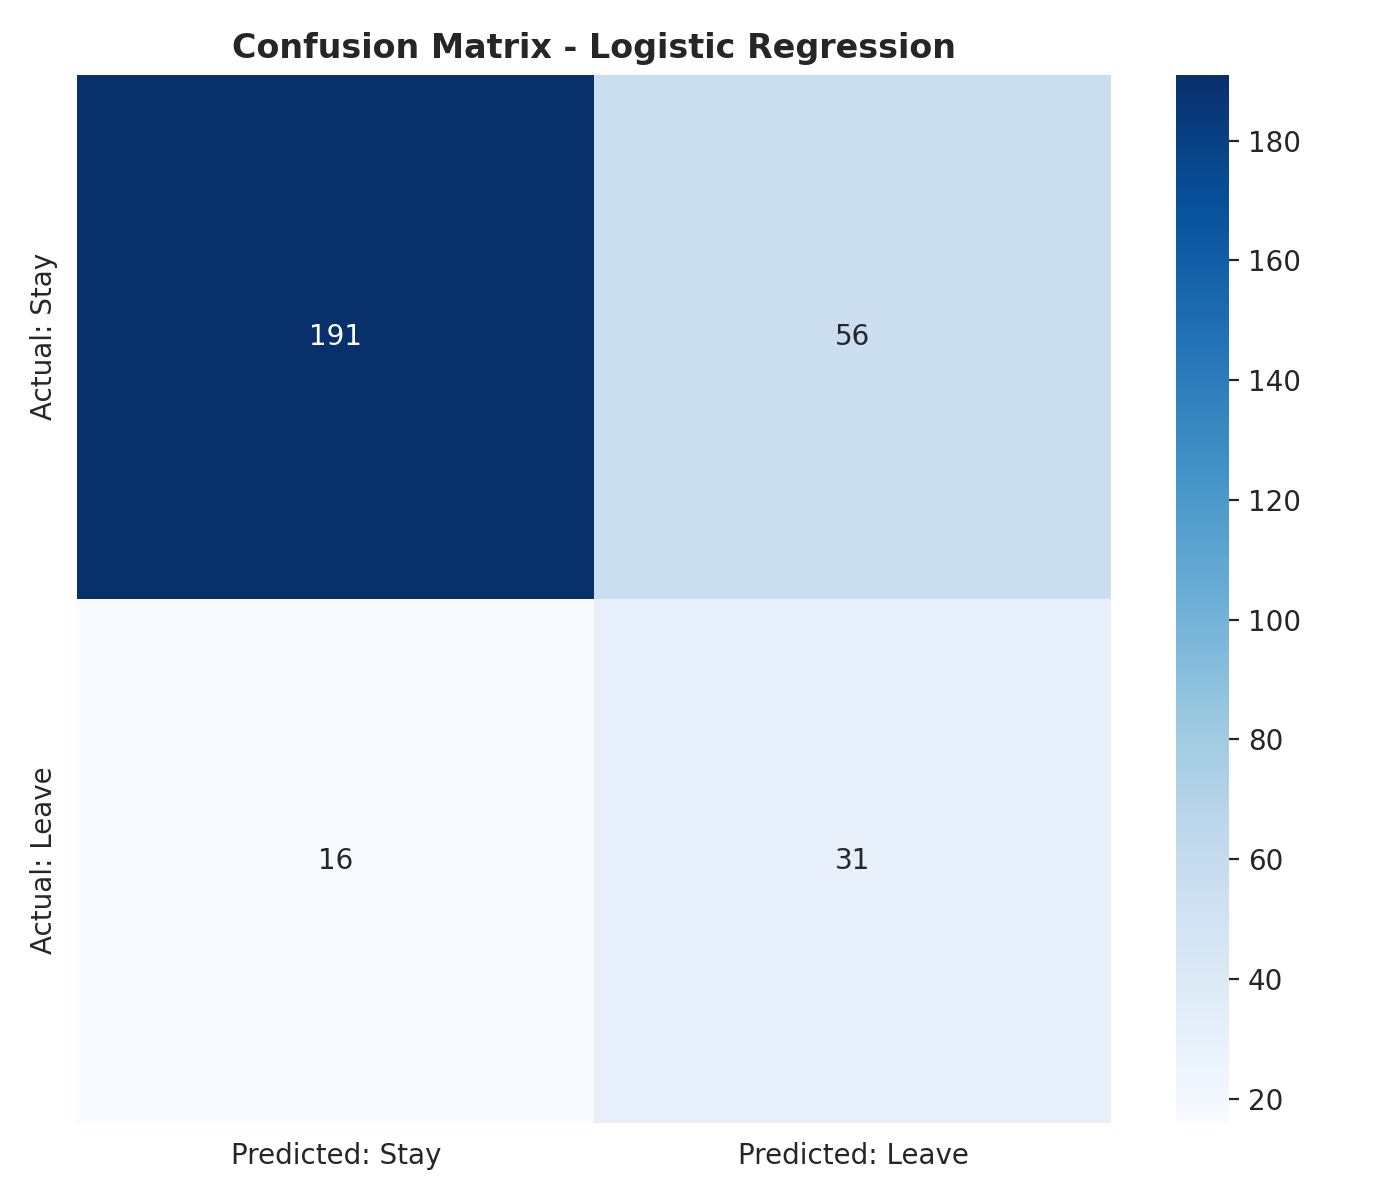

In [1]:
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: Stay','Predicted: Leave'],
            yticklabels=['Actual: Stay','Actual: Leave'])
ax.set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart_3_confusion_matrix.png', dpi=200)
plt.show()

### Chart 4: Top 10 Feature Importances

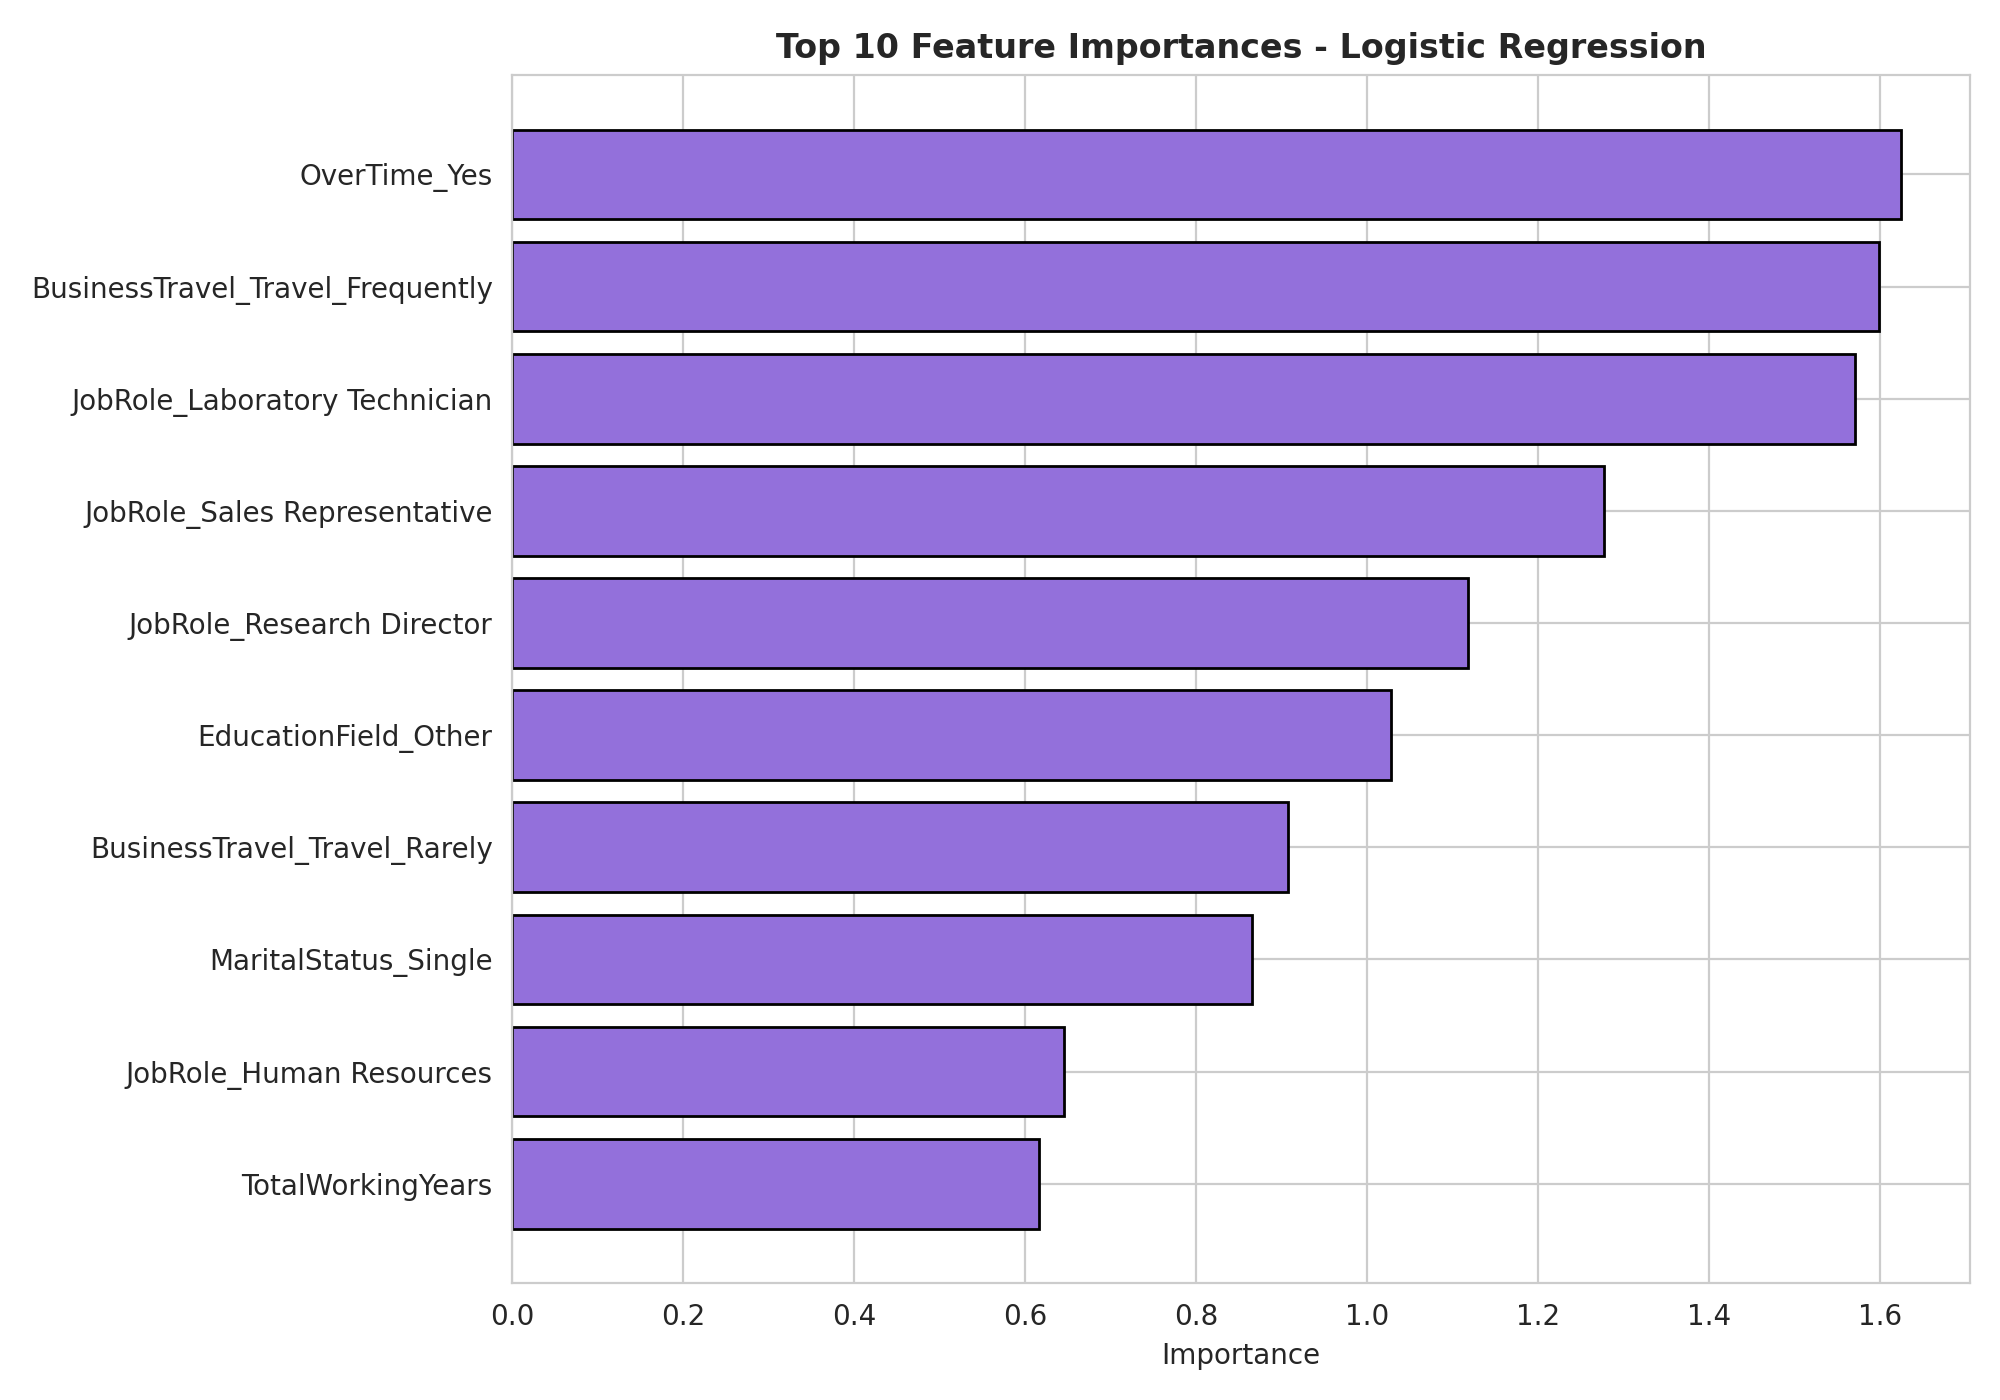

In [1]:
top10 = feat_imp.head(10).sort_values('Importance')
fig, ax = plt.subplots(figsize=(10,7))
ax.barh(top10['Feature'], top10['Importance'], color='mediumpurple', edgecolor='black')
ax.set_title(f'Top 10 Feature Importances - {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart_4_feature_importance.png', dpi=200)
plt.show()

### Chart 5 (Bonus): ROC Curve Comparison

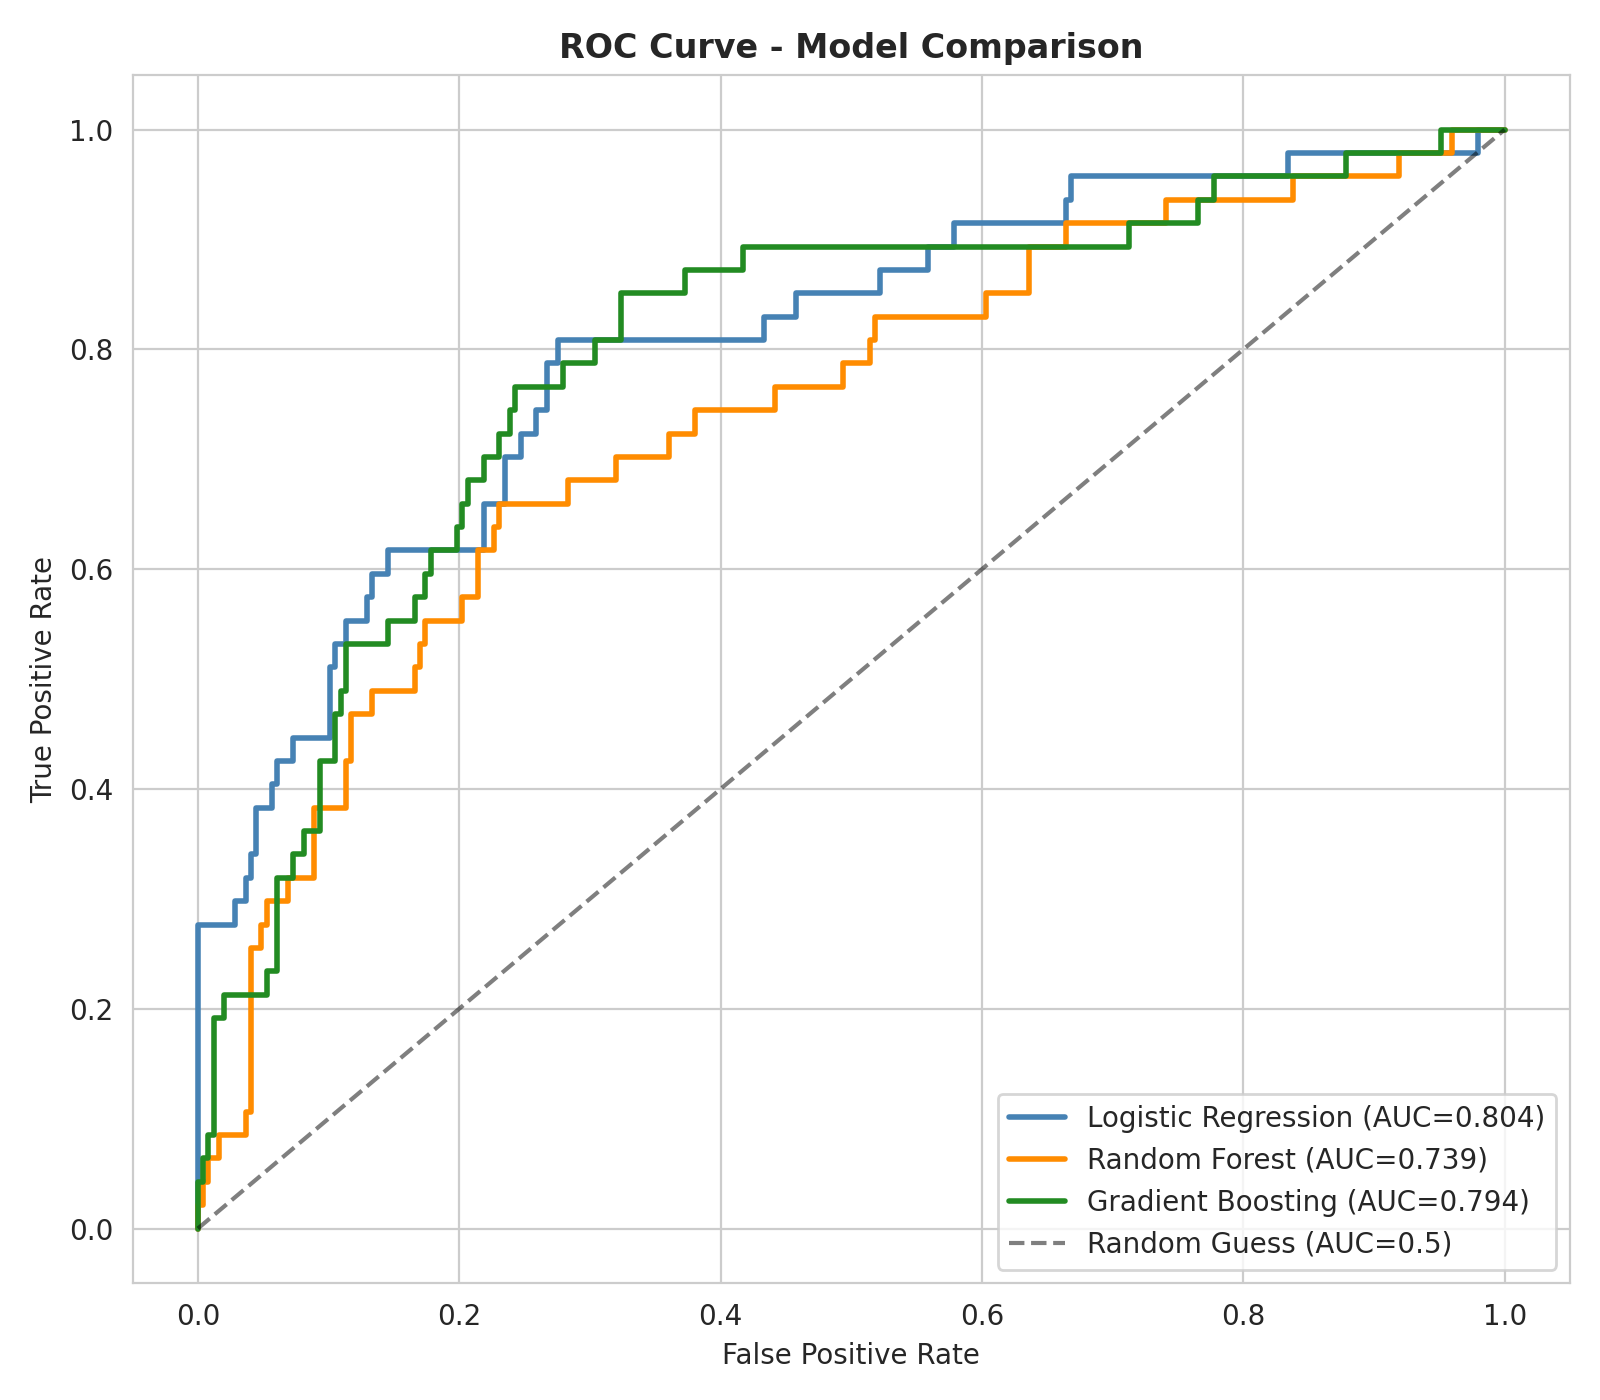

In [1]:
fig, ax = plt.subplots(figsize=(8,7))
colors = {'Logistic Regression':'steelblue','Random Forest':'darkorange','Gradient Boosting':'forestgreen'}
for name, proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={results[name]['ROC-AUC']:.3f})", color=colors[name], linewidth=2)
ax.plot([0,1],[0,1],'k--', label='Random Guess (AUC=0.5)', alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Model Comparison', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('charts/chart_5_roc_curve.png', dpi=200)
plt.show()

## Task 7: HR Insights & Business Recommendations

**Which 3 factors most strongly predict that an employee will leave?**
Working overtime, frequent business travel, and certain job roles (Laboratory Technician, Sales Representative) are the strongest predictors. Overtime is the single strongest signal in the entire model.

**Which department or job role should HR prioritize for retention efforts?**
Sales, and specifically Sales Representatives, deserve the most urgent attention — they leave at nearly 40%, more than double any other role.

**Does salary alone explain attrition, or are there other stronger factors?**
Salary plays a real part (employees who leave earn ~30% less on average), but it is not the dominant factor in the model. Overtime and travel frequency rank above salary-related features in importance — suggesting workload and lifestyle strain matter as much or more than pay.

**Two concrete HR recommendations:**
1. Audit overtime policy in the Sales department specifically, and proactively schedule retention conversations with any Sales Representative currently working sustained overtime — this is the single highest-risk combination in the data.
2. Strengthen onboarding and early-engagement support for employees in their first year, since attrition is highest (34.9%) in this window and drops sharply afterward — a focused 90-day check-in program could meaningfully reduce early exits.

**Limitation HR should be aware of:**
This model catches about 2 out of every 3 actual leavers (66% Recall) but also raises false alarms on people who were going to stay. It should be used as an early-warning signal to prioritize retention conversations — not as a definitive judgment about any individual employee's intentions.

---
**Prepared by:** Safiya Naguri | **XYlofy AI Internship** | 2026